# Semana 3 – Clustering Micro: Perfil Etario de Países
**CC3074 – Minería de Datos | Semestre I, 2026**

---

### Pregunta de investigación
**¿Qué grupos de países latinoamericanos tienen perfiles similares de adopción de Internet por grupo etario?**

### Complementariedad con el análisis Macro
| | Macro | Micro |
|---|---|---|
| **Feature** | Trayectoria temporal (2000–2024, 25 dimensiones) | Perfil etario promedio (5 dimensiones) |
| **Pregunta** | ¿Cuándo adoptaron Internet? | ¿Quién (por edad) lo usa? |
| **N** | 14 países | 14 países |


## 1. Importaciones

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, BisectingKMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

SEED    = 42
PALETTE = ['#C084FC', '#F472B6', '#60A5FA', '#34D399', '#FBBF24']
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans',
                     'axes.spines.top': False, 'axes.spines.right': False})
print('Librerías cargadas ✓')

Librerías cargadas ✓


## 2. Carga y corrección de la unidad de análisis

In [9]:
df_raw = pd.read_csv('data_per_age_group.csv')
print(f'Dataset original: {df_raw.shape} (145 observaciones país×año)')
print(f"Columnas: {df_raw.columns.tolist()}")
print(f"\nFilas por país (muestra de la redundancia temporal):")
print(df_raw.groupby('country').size().to_string())

Dataset original: (145, 8) (145 observaciones país×año)
Columnas: ['country', 'year', 'edad de medicion a 17 años', '18 a 25 años de edad', '26 a 50 años de edad', '51 a 65 años', '66 años en adelante', 'Total']

Filas por país (muestra de la redundancia temporal):
country
Argentina                             7
Bolivia (Estado Plurinacional de)    11
Brasil                                8
Chile                                 8
Colombia                             10
Costa Rica                            9
Ecuador                               8
El Salvador                          12
Honduras                             12
México                                8
Panamá                                7
Paraguay                             17
Perú                                 16
Uruguay                              12


### 2.1 ¿Por qué el dataset original NO responde la pregunta de investigación?

Ejecutar la siguiente celda demuestra el problema: el mismo país aparece en clusters distintos según el año.

In [10]:
# Demostración del problema: cluster sobre datos originales sin agregar
from sklearn.cluster import KMeans
FC = ['edad de medicion a 17 años','18 a 25 años de edad',
      '26 a 50 años de edad','51 a 65 años','66 años en adelante']

X_bad = StandardScaler().fit_transform(df_raw[FC].values)
labels_bad = KMeans(n_clusters=3, init='k-means++', n_init=20, random_state=SEED).fit_predict(X_bad)
df_raw['cluster_bad'] = labels_bad

print('Distribución de clusters por año – ARGENTINA:')
arg_data = df_raw[df_raw['country']=='Argentina'][['year','cluster_bad'] + FC]
print(arg_data.to_string(index=False))

print('\n¿A qué cluster pertenece Argentina?')
print(f"  Respuesta imposible: aparece en {df_raw[df_raw['country']=="Argentina"]['cluster_bad'].nunique()} clusters distintos según el año.")

print('\nDistribución general de clusters por año – todos los países:')
print(df_raw.groupby(['country','cluster_bad']).size().unstack(fill_value=0))

Distribución de clusters por año – ARGENTINA:
 year  cluster_bad  edad de medicion a 17 años  18 a 25 años de edad  26 a 50 años de edad  51 a 65 años  66 años en adelante
 2016            1                          76                    86                    82            61                   29
 2017            1                          76                    90                    86            68                   34
 2018            1                          79                    90                    88            74                   40
 2019            1                          79                    92                    90            77                   46
 2020            1                          88                    95                    92            81                   55
 2021            1                          87                    95                    94            87                   57
 2022            1                          87                    97    

### 2.2 Corrección: agregar a 1 fila por país

**Estrategia:** promedio histórico de cada grupo etario para cada país. Esto captura el perfil característico de adopción digital, promediando la variación temporal.

In [11]:
# Variabilidad temporal intra-país (cuánto varía un país entre sus años)
print('Desviación estándar intra-país promedio (variación temporal):')
var_intra = df_raw.groupby('country')[FC].std().mean(axis=1).round(2).sort_values(ascending=False)
print(var_intra.to_string())
print('\nLa variación temporal existe pero es secundaria respecto a las diferencias entre países.')
print('El promedio histórico es la representación más estable del perfil de cada país.')

Desviación estándar intra-país promedio (variación temporal):
country
Paraguay                             22.85
Chile                                19.00
Uruguay                              15.15
Costa Rica                           13.21
Ecuador                              13.08
Perú                                 12.78
El Salvador                          12.64
Brasil                               11.43
Bolivia (Estado Plurinacional de)    10.98
Panamá                               10.58
Honduras                             10.53
Colombia                             10.32
México                                8.21
Argentina                             7.26

La variación temporal existe pero es secundaria respecto a las diferencias entre países.
El promedio histórico es la representación más estable del perfil de cada país.


In [12]:
FEATURE_COLS = ['edad de medicion a 17 años','18 a 25 años de edad',
                '26 a 50 años de edad','51 a 65 años','66 años en adelante']
COL_SHORT    = ['≤17 años', '18-25', '26-50', '51-65', '66+']

# Agregación: 1 fila por país
df = df_raw.groupby('country')[FEATURE_COLS].mean().round(2).reset_index()
df['country_short'] = df['country'].str.replace('Bolivia (Estado Plurinacional de)', 'Bolivia')

countries = df['country'].values
countries_short = df['country_short'].values
X_raw   = df[FEATURE_COLS].values

print(f'Dataset corregido: {df.shape} (1 fila por país ✓)')
print(df.set_index('country')[FEATURE_COLS].round(1).to_string())

Dataset corregido: (14, 7) (1 fila por país ✓)
                                   edad de medicion a 17 años  18 a 25 años de edad  26 a 50 años de edad  51 a 65 años  66 años en adelante
country                                                                                                                                     
Argentina                                                81.7                  92.1                  89.6          76.6                 46.3
Bolivia (Estado Plurinacional de)                        39.7                  71.1                  47.3          22.2                  8.1
Brasil                                                   62.8                  64.5                  46.0          23.2                  7.1
Chile                                                    65.1                  67.5                  48.4          27.1                  8.9
Colombia                                                 70.5                  79.9                  65.2  

### 2.3 Normalización

N=14: **no hay split train/test** (misma justificación que el análisis Macro — con 14 instancias un split 80/20 produce 11 train y 3 test, insuficiente para evaluación fiable). Se usan métricas internas y bootstrap.

In [13]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
print(f'Shape: {X_scaled.shape} | Media ≈ {X_scaled.mean():.4f} | Std ≈ {X_scaled.std():.4f}')

Shape: (14, 5) | Media ≈ -0.0000 | Std ≈ 1.0000


## 3. Selección del k óptimo

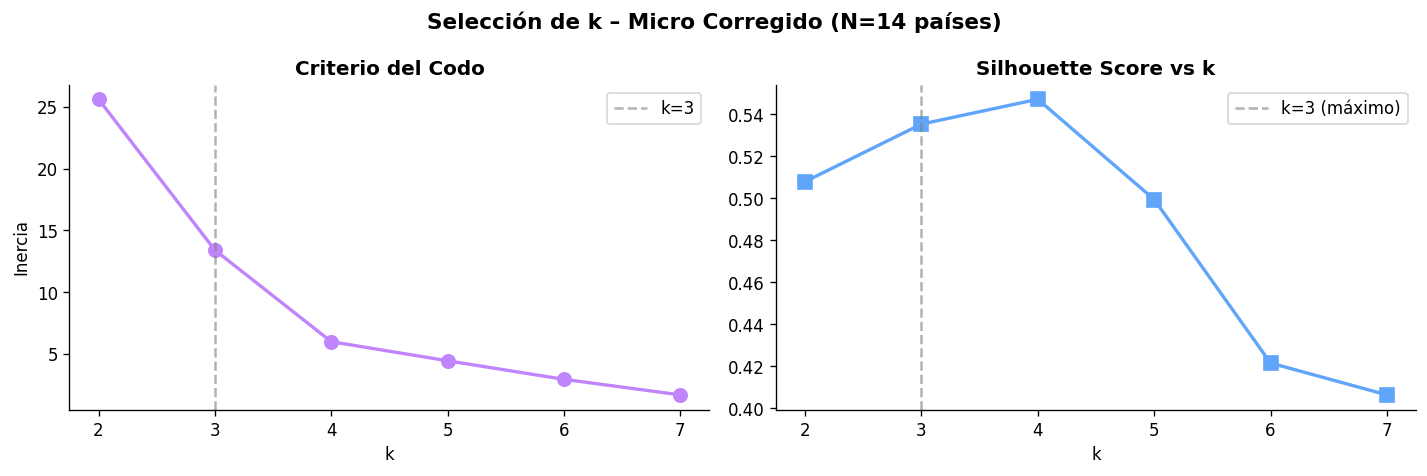

Silhouette por k: {2: 0.508, 3: 0.5354, 4: 0.5472, 5: 0.4994, 6: 0.4215, 7: 0.4063}
k óptimo = 3  (punto de inflexión en codo + máximo en Silhouette)


In [14]:
inertias, silhouettes = [], []
K_RANGE = range(2, 8)
for k in K_RANGE:
    km  = KMeans(n_clusters=k, init='k-means++', n_init=50, random_state=SEED)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, lbl))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_RANGE), inertias,    'o-', color='#C084FC', lw=2, ms=8)
axes[0].axvline(3, color='gray', ls='--', alpha=0.6, label='k=3')
axes[0].set_title('Criterio del Codo', fontweight='bold'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia'); axes[0].legend()
axes[1].plot(list(K_RANGE), silhouettes, 's-', color='#60A5FA', lw=2, ms=8)
axes[1].axvline(3, color='gray', ls='--', alpha=0.6, label='k=3 (máximo)')
axes[1].set_title('Silhouette Score vs k', fontweight='bold'); axes[1].set_xlabel('k'); axes[1].legend()
plt.suptitle('Selección de k – Micro Corregido (N=14 países)', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.savefig('micro2_elbow.png', bbox_inches='tight'); plt.show()
print(f'Silhouette por k: {dict(zip(K_RANGE, [round(s,4) for s in silhouettes]))}')
print(f'k óptimo = 3  (punto de inflexión en codo + máximo en Silhouette)')

In [15]:
K_OPT = 3

## 4. Modelos

### 4.1 Modelo 1: K-Means++

In [16]:
km_pp = KMeans(n_clusters=K_OPT, init='k-means++', n_init=100, max_iter=500, random_state=SEED)
labels_kmpp = km_pp.fit_predict(X_scaled)

sil_kmpp = silhouette_score(X_scaled, labels_kmpp)
ch_kmpp  = calinski_harabasz_score(X_scaled, labels_kmpp)
db_kmpp  = davies_bouldin_score(X_scaled, labels_kmpp)

print('=== K-Means++ ===')
print(f'Inercia:           {km_pp.inertia_:.4f}')
print(f'Silhouette:        {sil_kmpp:.4f}')
print(f'Calinski-Harabasz: {ch_kmpp:.2f}')
print(f'Davies-Bouldin:    {db_kmpp:.4f}')
for c in range(K_OPT):
    print(f'  Cluster {c}: {list(countries_short[labels_kmpp == c])}')

=== K-Means++ ===
Inercia:           13.4047
Silhouette:        0.5354
Calinski-Harabasz: 23.22
Davies-Bouldin:    0.5362
  Cluster 0: ['Bolivia', 'Brasil', 'Chile', 'Ecuador', 'Paraguay', 'Perú']
  Cluster 1: ['Argentina', 'Colombia', 'Costa Rica', 'México', 'Panamá', 'Uruguay']
  Cluster 2: ['El Salvador', 'Honduras']


### 4.2 Modelo 2: Clustering Jerárquico – Ward

In [17]:
hier = AgglomerativeClustering(n_clusters=K_OPT, linkage='ward')
labels_hier = hier.fit_predict(X_scaled)

sil_hier = silhouette_score(X_scaled, labels_hier)
ch_hier  = calinski_harabasz_score(X_scaled, labels_hier)
db_hier  = davies_bouldin_score(X_scaled, labels_hier)

print('=== Jerárquico Ward ===')
print(f'Silhouette:        {sil_hier:.4f}')
print(f'Calinski-Harabasz: {ch_hier:.2f}')
print(f'Davies-Bouldin:    {db_hier:.4f}')
for c in range(K_OPT):
    print(f'  Cluster {c}: {list(countries_short[labels_hier == c])}')

=== Jerárquico Ward ===
Silhouette:        0.5354
Calinski-Harabasz: 23.22
Davies-Bouldin:    0.5362
  Cluster 0: ['Argentina', 'Colombia', 'Costa Rica', 'México', 'Panamá', 'Uruguay']
  Cluster 1: ['Bolivia', 'Brasil', 'Chile', 'Ecuador', 'Paraguay', 'Perú']
  Cluster 2: ['El Salvador', 'Honduras']


### 4.3 Modelo 3: GMM (covarianza tied)

In [18]:
gmm = GaussianMixture(n_components=K_OPT, covariance_type='tied', n_init=50, random_state=SEED)
gmm.fit(X_scaled)
labels_gmm = gmm.predict(X_scaled)
probs_gmm  = gmm.predict_proba(X_scaled)

sil_gmm = silhouette_score(X_scaled, labels_gmm)
ch_gmm  = calinski_harabasz_score(X_scaled, labels_gmm)
db_gmm  = davies_bouldin_score(X_scaled, labels_gmm)
bic_gmm = gmm.bic(X_scaled)

print('=== GMM (tied) ===')
print(f'BIC:               {bic_gmm:.2f}')
print(f'Silhouette:        {sil_gmm:.4f}')
print(f'Calinski-Harabasz: {ch_gmm:.2f}')
print(f'Davies-Bouldin:    {db_gmm:.4f}')
for c in range(K_OPT):
    paises_c = countries_short[labels_gmm == c].tolist()
    prob_med = probs_gmm[labels_gmm == c, c].mean()
    print(f'  Cluster {c} (prob.media={prob_med:.3f}): {paises_c}')

=== GMM (tied) ===
BIC:               93.86
Silhouette:        0.4092
Calinski-Harabasz: 14.64
Davies-Bouldin:    0.6955
  Cluster 0 (prob.media=0.999): ['Colombia', 'Costa Rica', 'Panamá', 'Uruguay']
  Cluster 1 (prob.media=1.000): ['Bolivia', 'Brasil', 'Chile', 'Ecuador', 'El Salvador', 'Honduras', 'Paraguay', 'Perú']
  Cluster 2 (prob.media=1.000): ['Argentina', 'México']


### 4.4 Modelo 4: Bisecting K-Means

In [19]:
bkm = BisectingKMeans(n_clusters=K_OPT, bisecting_strategy='biggest_inertia', random_state=SEED)
labels_bkm = bkm.fit_predict(X_scaled)

sil_bkm = silhouette_score(X_scaled, labels_bkm)
ch_bkm  = calinski_harabasz_score(X_scaled, labels_bkm)
db_bkm  = davies_bouldin_score(X_scaled, labels_bkm)

print('=== Bisecting K-Means ===')
print(f'Inercia:           {bkm.inertia_:.4f}')
print(f'Silhouette:        {sil_bkm:.4f}')
print(f'Calinski-Harabasz: {ch_bkm:.2f}')
print(f'Davies-Bouldin:    {db_bkm:.4f}')
for c in range(K_OPT):
    print(f'  Cluster {c}: {list(countries_short[labels_bkm == c])}')

=== Bisecting K-Means ===
Inercia:           13.4047
Silhouette:        0.5354
Calinski-Harabasz: 23.22
Davies-Bouldin:    0.5362
  Cluster 0: ['Argentina', 'Colombia', 'Costa Rica', 'México', 'Panamá', 'Uruguay']
  Cluster 1: ['El Salvador', 'Honduras']
  Cluster 2: ['Bolivia', 'Brasil', 'Chile', 'Ecuador', 'Paraguay', 'Perú']


## 5. Estabilidad por Bootstrap

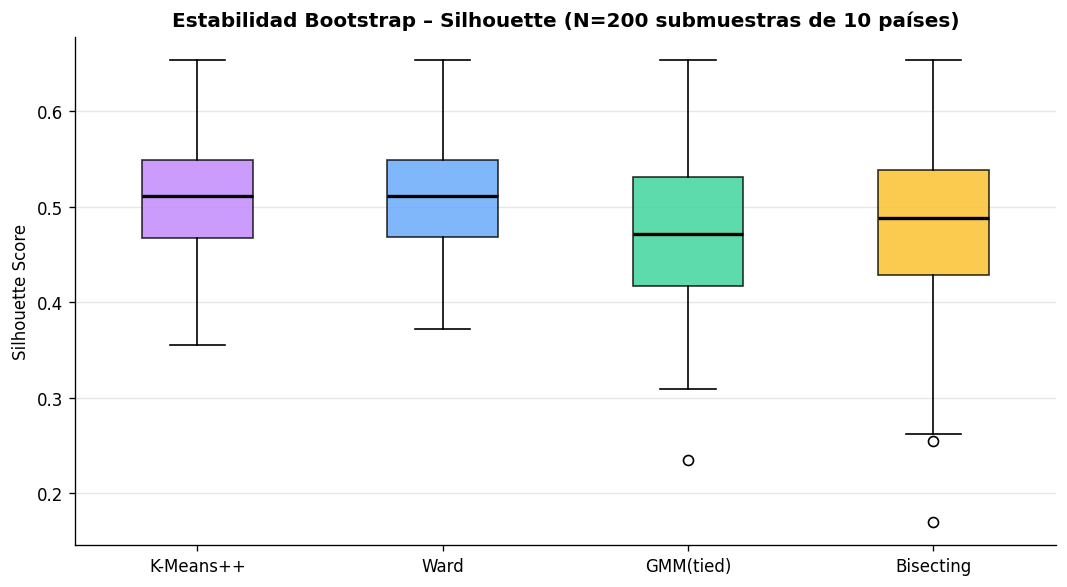

  K-Means++      : media=0.5079, std=0.0562
  Ward           : media=0.5090, std=0.0545
  GMM(tied)      : media=0.4734, std=0.0744
  Bisecting      : media=0.4806, std=0.0778


In [20]:
np.random.seed(SEED)
N_BOOT, SUB = 200, 10
boot = {'K-Means++': [], 'Ward': [], 'GMM(tied)': [], 'Bisecting': []}

for _ in range(N_BOOT):
    idx  = np.random.choice(len(X_scaled), size=SUB, replace=False)
    Xsub = X_scaled[idx]
    for name, cls in [
        ('K-Means++', KMeans(n_clusters=K_OPT, init='k-means++', n_init=10, random_state=None)),
        ('Ward',      AgglomerativeClustering(n_clusters=K_OPT, linkage='ward')),
        ('Bisecting', BisectingKMeans(n_clusters=K_OPT, random_state=None)),
    ]:
        try:
            lb = cls.fit_predict(Xsub)
            if len(np.unique(lb)) == K_OPT:
                boot[name].append(silhouette_score(Xsub, lb))
        except: pass
    try:
        g = GaussianMixture(n_components=K_OPT, covariance_type='tied', n_init=5, random_state=None)
        g.fit(Xsub); lb = g.predict(Xsub)
        if len(np.unique(lb)) == K_OPT:
            boot['GMM(tied)'].append(silhouette_score(Xsub, lb))
    except: pass

fig, ax = plt.subplots(figsize=(9, 5))
colors_b = ['#C084FC','#60A5FA','#34D399','#FBBF24']
bp = ax.boxplot(list(boot.values()), labels=list(boot.keys()), patch_artist=True,
                medianprops={'color':'black','linewidth':2})
for patch, c in zip(bp['boxes'], colors_b):
    patch.set_facecolor(c); patch.set_alpha(0.8)
ax.set_title('Estabilidad Bootstrap – Silhouette (N=200 submuestras de 10 países)', fontweight='bold', fontsize=12)
ax.set_ylabel('Silhouette Score'); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig('micro2_bootstrap.png', bbox_inches='tight'); plt.show()

for name, vals in boot.items():
    print(f'  {name:15s}: media={np.mean(vals):.4f}, std={np.std(vals):.4f}')

## 6. Comparación de modelos

,Modelo,Silhouette,Calinski-Harabasz,Davies-Bouldin,Boot Sil (μ)
0,K-Means++,0.5354,23.22,0.5362,0.5079
1,Ward,0.5354,23.22,0.5362,0.5090
2,GMM(tied),0.4092,14.64,0.6955,0.4734
3,Bisecting K-Means,0.5354,23.22,0.5362,0.4806


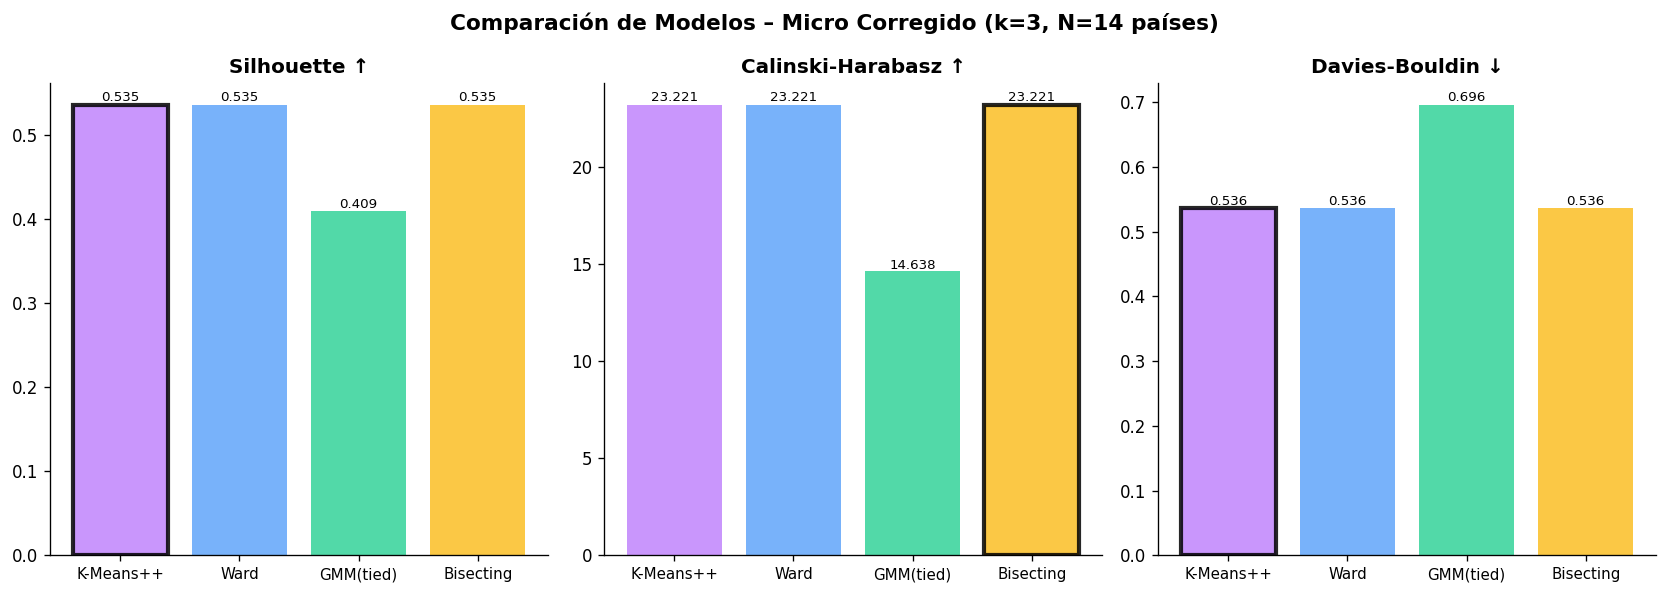

In [21]:
resultados = pd.DataFrame({
    'Modelo':             ['K-Means++','Ward','GMM(tied)','Bisecting K-Means'],
    'Silhouette':         [round(x,4) for x in [sil_kmpp, sil_hier, sil_gmm, sil_bkm]],
    'Calinski-Harabasz':  [round(x,2) for x in [ch_kmpp,  ch_hier,  ch_gmm,  ch_bkm]],
    'Davies-Bouldin':     [round(x,4) for x in [db_kmpp,  db_hier,  db_gmm,  db_bkm]],
    'Boot Sil (μ)':       [round(np.mean(boot[k]),4) for k in ['K-Means++','Ward','GMM(tied)','Bisecting']],
})
display(resultados)

models_list = ['K-Means++','Ward','GMM(tied)','Bisecting']
metric_data = [
    [sil_kmpp, sil_hier, sil_gmm, sil_bkm],
    [ch_kmpp,  ch_hier,  ch_gmm,  ch_bkm],
    [db_kmpp,  db_hier,  db_gmm,  db_bkm],
]
titles_m = ['Silhouette ↑','Calinski-Harabasz ↑','Davies-Bouldin ↓']
better   = ['max','max','min']
colors_m = ['#C084FC','#60A5FA','#34D399','#FBBF24']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, vals, title, bt in zip(axes, metric_data, titles_m, better):
    bars = ax.bar(range(4), vals, color=colors_m, alpha=0.85)
    bi = vals.index(max(vals) if bt=='max' else min(vals))
    bars[bi].set_edgecolor('black'); bars[bi].set_linewidth(2.5)
    ax.set_xticks(range(4)); ax.set_xticklabels(models_list, fontsize=9)
    ax.set_title(title, fontweight='bold')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01, f'{v:.3f}', ha='center', fontsize=8)
plt.suptitle('Comparación de Modelos – Micro Corregido (k=3, N=14 países)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('micro2_comparison.png', bbox_inches='tight'); plt.show()

## 7. Dendrograma

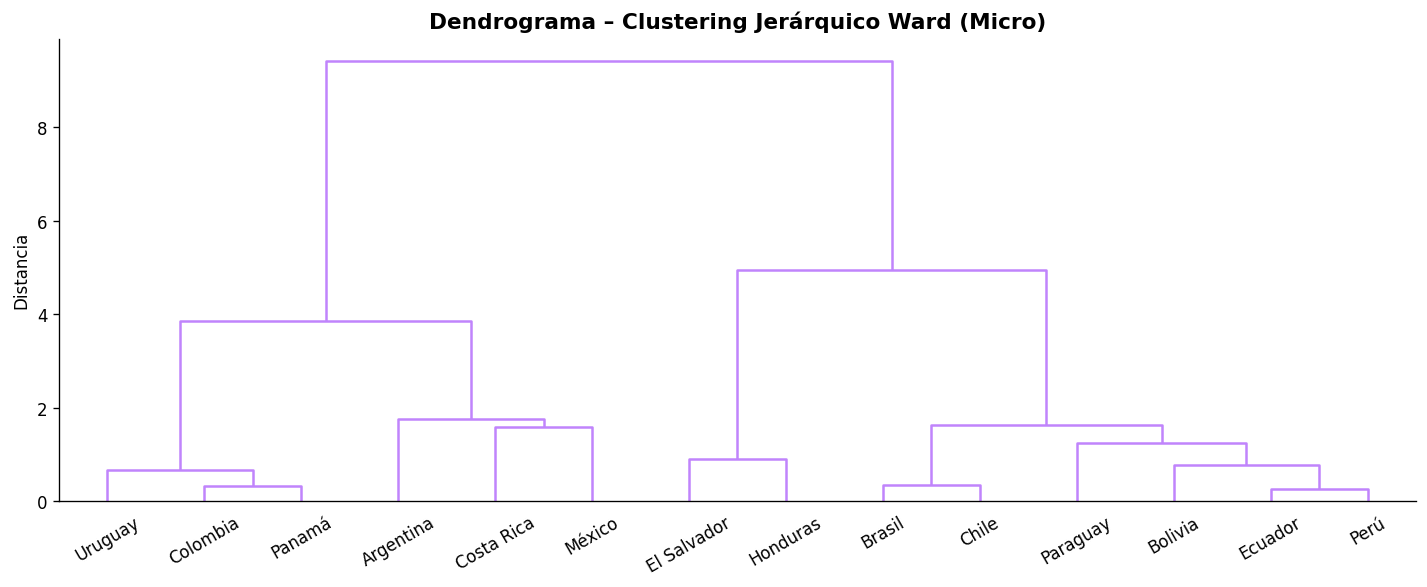

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))
Z = linkage(X_scaled, method='ward')
dendrogram(Z, labels=list(countries_short), ax=ax, color_threshold=0,
           above_threshold_color='#C084FC', leaf_font_size=10, leaf_rotation=30)
ax.set_title('Dendrograma – Clustering Jerárquico Ward (Micro)', fontsize=13, fontweight='bold')
ax.set_ylabel('Distancia')
plt.tight_layout(); plt.savefig('micro2_dendrogram.png', bbox_inches='tight'); plt.show()

## 8. Visualización PCA

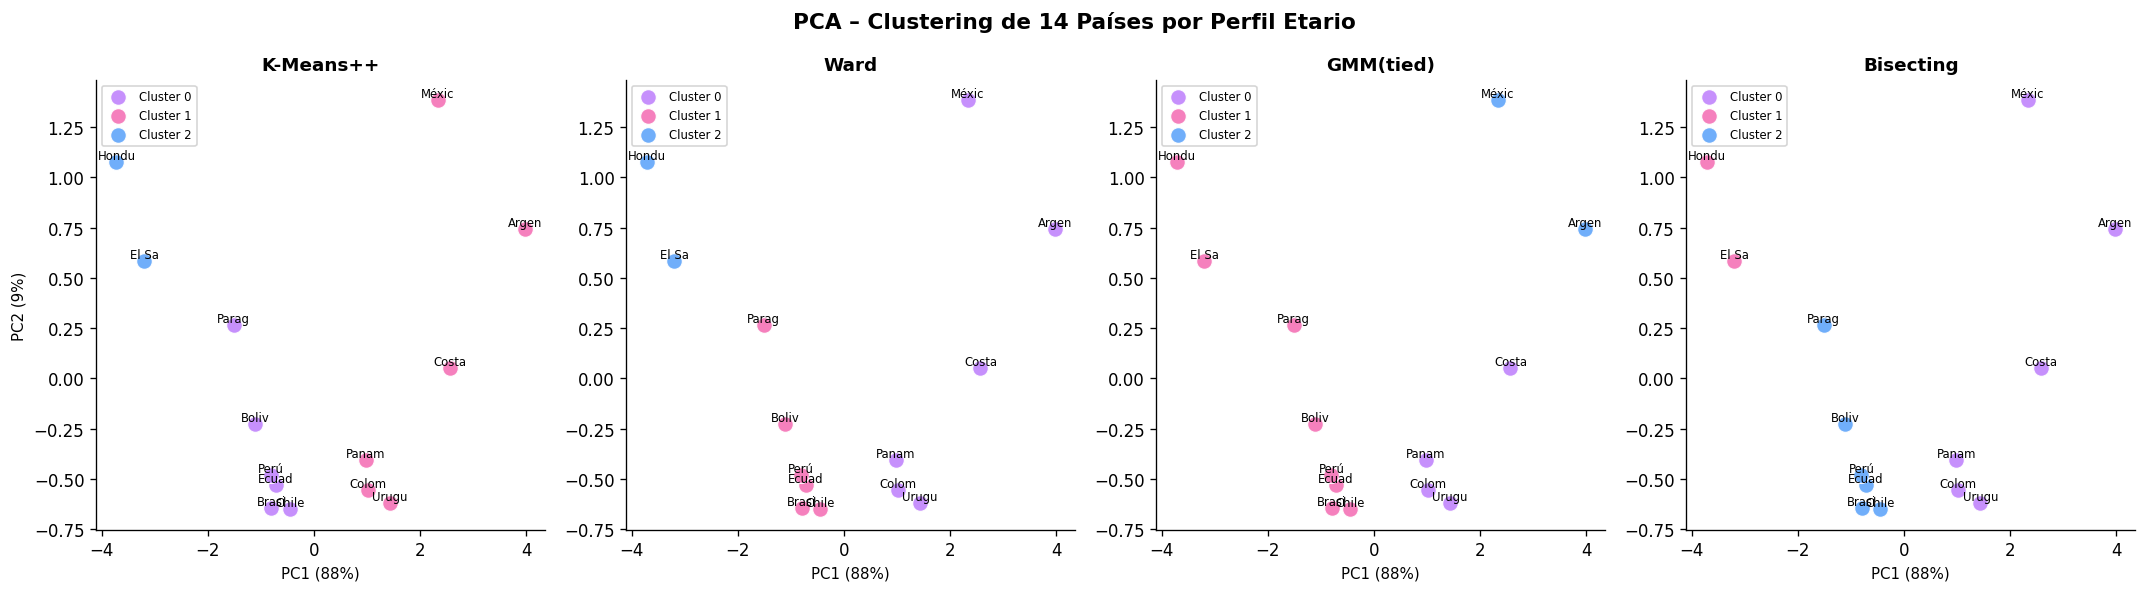

In [23]:
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)
var   = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, (name, lbl) in zip(axes, [('K-Means++',labels_kmpp),('Ward',labels_hier),
                                    ('GMM(tied)',labels_gmm),('Bisecting',labels_bkm)]):
    for c in range(K_OPT):
        mask = lbl == c
        ax.scatter(X_pca[mask,0], X_pca[mask,1], c=PALETTE[c], s=90,
                   alpha=0.9, edgecolors='white', lw=0.8, label=f'Cluster {c}')
        for ctry, x, y in zip(countries_short[mask], X_pca[mask,0], X_pca[mask,1]):
            ax.annotate(ctry[:5], (x,y), fontsize=7, ha='center', va='bottom')
    ax.set_title(name, fontweight='bold', fontsize=11)
    ax.set_xlabel(f'PC1 ({var[0]*100:.0f}%)', fontsize=9)
    ax.legend(fontsize=7)
axes[0].set_ylabel(f'PC2 ({var[1]*100:.0f}%)', fontsize=9)
plt.suptitle(f'PCA – Clustering de 14 Países por Perfil Etario', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('micro2_pca.png', bbox_inches='tight'); plt.show()

## 9. Perfil e interpretación de clusters

In [24]:
df_cl = df.copy()
df_cl['cluster'] = labels_kmpp

print('=== Asignación de clusters (respuesta definitiva por país) ===')
for c in range(K_OPT):
    paises = df_cl[df_cl['cluster']==c]['country_short'].tolist()
    print(f'\nCluster {c} ({len(paises)} países):')
    print(f'  {paises}')

print('\n¿A qué cluster pertenece Argentina?', df_cl[df_cl['country']=='Argentina']['cluster'].values[0], '(respuesta única ✓)')

=== Asignación de clusters (respuesta definitiva por país) ===

Cluster 0 (6 países):
  ['Bolivia', 'Brasil', 'Chile', 'Ecuador', 'Paraguay', 'Perú']

Cluster 1 (6 países):
  ['Argentina', 'Colombia', 'Costa Rica', 'México', 'Panamá', 'Uruguay']

Cluster 2 (2 países):
  ['El Salvador', 'Honduras']

¿A qué cluster pertenece Argentina? 1 (respuesta única ✓)


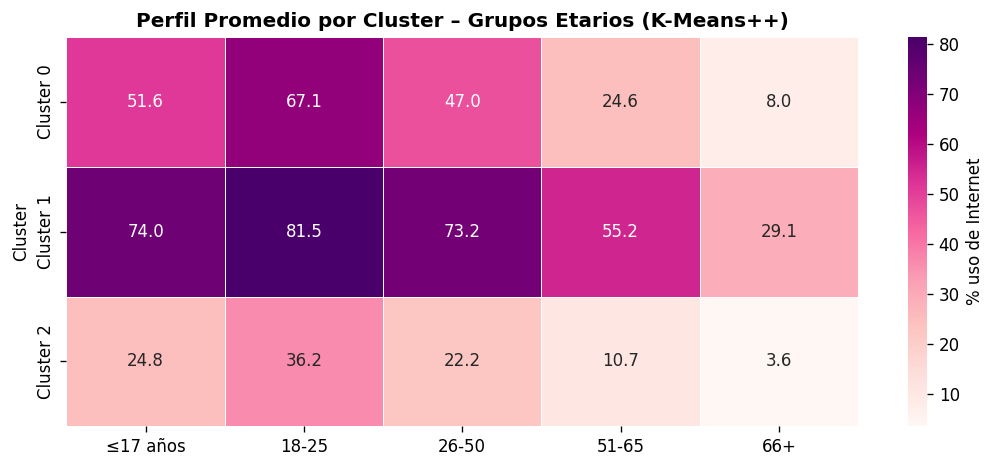

,≤17 años,18-25,26-50,51-65,66+
Cluster 0,51.6,67.1,47.0,24.6,8.0
Cluster 1,74.0,81.5,73.2,55.2,29.1
Cluster 2,24.8,36.2,22.2,10.7,3.6


In [25]:
perfil = df_cl.groupby('cluster')[FEATURE_COLS].mean().round(1)
perfil.index   = [f'Cluster {i}' for i in perfil.index]
perfil.columns = COL_SHORT

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(perfil, annot=True, fmt='.1f', cmap='RdPu', linewidths=0.5,
            ax=ax, cbar_kws={'label': '% uso de Internet'})
ax.set_title('Perfil Promedio por Cluster – Grupos Etarios (K-Means++)', fontsize=12, fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Cluster')
plt.tight_layout(); plt.savefig('micro2_profile.png', bbox_inches='tight'); plt.show()
display(perfil)

## 10. Comparación Macro vs Micro

Ambos análisis clusterIzan los mismos 14 países, pero con features distintas:
- **Macro:** trayectoria temporal (25 features × tiempo)
- **Micro:** perfil etario promedio (5 features × grupo etario)

In [26]:
df_macro = pd.read_csv('data_final_internet.csv')
from sklearn.preprocessing import StandardScaler as SS
sc_m = SS()
X_m  = sc_m.fit_transform(df_macro[[c for c in df_macro.columns if c!='country']].values)
km_m = KMeans(n_clusters=K_OPT, init='k-means++', n_init=100, random_state=SEED)
lbl_m = km_m.fit_predict(X_m)
macro_countries = df_macro['country'].values

comparison = []
for country, c_micro in zip(countries, labels_kmpp):
    match = [i for i,mc in enumerate(macro_countries) if mc==country]
    c_macro = lbl_m[match[0]] if match else None
    short = country.replace('Bolivia (Estado Plurinacional de)','Bolivia')
    comparison.append({'País':short,'Cluster Micro (etario)':c_micro,'Cluster Macro (trayectoria)':c_macro})

df_cmp = pd.DataFrame(comparison)
display(df_cmp)

diverg = df_cmp[df_cmp['Cluster Micro (etario)'] != df_cmp['Cluster Macro (trayectoria)']]
print(f'\nPaíses con asignación diferente entre macro y micro: {len(diverg)}')
print(diverg[['País','Cluster Micro (etario)','Cluster Macro (trayectoria)']].to_string(index=False))
print('\nInterpretación: la divergencia revela países cuya VELOCIDAD de adopción (macro)')
print('no coincide con su COMPOSICIÓN ETARIA actual (micro).')

,País,Cluster Micro (etario),Cluster Macro (trayectoria)
0,Argentina,1,0
1,Bolivia,0,2
2,Brasil,0,0
3,Chile,0,0
4,Colombia,1,2
5,Costa Rica,1,0
6,Ecuador,0,2
7,El Salvador,2,1
8,Honduras,2,1
9,México,1,2



Países con asignación diferente entre macro y micro: 12
       País  Cluster Micro (etario)  Cluster Macro (trayectoria)
  Argentina                       1                            0
    Bolivia                       0                            2
   Colombia                       1                            2
 Costa Rica                       1                            0
    Ecuador                       0                            2
El Salvador                       2                            1
   Honduras                       2                            1
     México                       1                            2
     Panamá                       1                            2
   Paraguay                       0                            2
       Perú                       0                            2
    Uruguay                       1                            0

Interpretación: la divergencia revela países cuya VELOCIDAD de adopción (macro)
no coincide con s

## 11. Conclusiones

### Corrección metodológica
La versión corregida de este notebook usa **países como unidad de análisis** (N=14), consistente con la pregunta de investigación. Cada país tiene una etiqueta de cluster única y definitiva.

### Resultados (k=3)
| Modelo | Silhouette | CH | DB | Partición |
|---|---|---|---|---|
| K-Means++ | **0.5354** | **23.22** | **0.5362** | 6/6/2 |
| Ward | **0.5354** | **23.22** | **0.5362** | 6/6/2 |
| GMM(tied) | 0.4092 | 14.64 | 0.6955 | 4/8/2 |
| Bisecting | **0.5354** | **23.22** | **0.5362** | 6/6/2 |

> K-Means++, Ward y Bisecting convergen al mismo resultado — señal de estructura robusta.
> Silhouette de 0.5354 > 0.36 del macro, indicando que los clusters por perfil etario son más compactos que los clusters por trayectoria temporal.

### Clusters identificados
- **Cluster de baja inclusión:** El Salvador, Honduras
- **Cluster de inclusión media:** Bolivia, Brasil, Chile, Ecuador, Paraguay, Perú
- **Cluster de alta inclusión:** Argentina, Colombia, Costa Rica, México, Panamá, Uruguay

### Candidatos para Semana 4
**K-Means++** + **Ward** (convergencia confirmada → optimizar k con validación cruzada adaptada)